# Прогнозирование цен на недвижимость — разведочный анализ

## О датасете
Этот датасет содержит 4 600 исторических записей о продажах недвижимости, преимущественно относящихся к рынку недвижимости штата Вашингтон (включая Сиэтл, Беллевью, Редмонд и близлежащие районы). Он даёт комплексное представление о том, как структурные, исторические и географические характеристики влияют на стоимость объекта.

## Столбцы
* `date` — дата регистрации сделки с недвижимостью (формат: ГГГГ-ММ-ДД)
* `price` — итоговая цена продажи объекта в USD (целевая переменная)
* `bedrooms` — общее количество спален в объекте
* `bathrooms` — общее количество ванных комнат. Дробные значения (например, 1.5, 2.25) обозначают неполные санузлы (например, унитаз и раковина без душа)
* `sqft_living` — общая жилая площадь в квадратных футах
* `sqft_lot` — общая площадь земельного участка в квадратных футах
* `floors` — количество этажей в объекте
* `waterfront` — бинарный признак (1 или 0), указывающий, находится ли объект на берегу водоёма
* `view` — оценка качества вида из объекта (от 0 до 4)
* `condition` — оценка общего конструктивного и эстетического состояния объекта (от 1 до 5)

## Контекст
Разведочный анализ данных о продажах недвижимости в штате Вашингтон. Цель — понять, какие факторы связаны с ценой на жильё, и на простом примере показать, как результаты EDA могут использоваться агентством недвижимости при выборе городов для расширения деятельности.

## Вопросы
1. Каково общее качество данных: есть ли пропущенные значения, дубликаты или аномалии 
   (например, `price == 0`), и как их следует обрабатывать?
2. Как распределена цена (`price`) и есть ли выбросы?
3. Какие признаки сильнее всего коррелируют с ценой 
   (`sqft_living`, `bedrooms`, `bathrooms` и т.д.)?
4. Как цена изменяется в зависимости от города (`city`) — есть ли явные лидеры 
   и аутсайдеры по медианной цене и `price_per_sqft`?
5. Влияют ли `waterfront`, `view` и статус реконструкции (`yr_renovated`) на цену дома?

# Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Загрузка данных

In [2]:
data = pd.read_csv('../data/modified_data.csv')
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


# Качество данных

In [3]:
print('Пропущенные значения:')
print()
print(data.isna().sum())
print('=' * 42)
print(f'Дублирующиеся строки: {data.duplicated().sum()}')
print('=' * 42)
print('Типы данных:')
print()
print(data.dtypes)

Пропущенные значения:

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64
Дублирующиеся строки: 0
Типы данных:

date               object
price             float64
bedrooms          float64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
street             object
city               object
statezip           object
price_per_sqft    float64
dtype: object


In [4]:
data.describe().style.format(precision=1)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0,4600.0
mean,551963.0,3.4,2.2,2139.3,14852.5,1.5,0.0,0.2,3.5,1827.3,312.1,1970.8,808.6,265.9
std,563834.7,0.9,0.8,963.2,35884.4,0.5,0.1,0.8,0.7,862.2,464.1,29.7,979.4,357.5
min,0.0,0.0,0.0,370.0,638.0,1.0,0.0,0.0,1.0,370.0,0.0,1900.0,0.0,0.0
25%,322875.0,3.0,1.8,1460.0,5000.8,1.0,0.0,0.0,3.0,1190.0,0.0,1951.0,0.0,180.8
50%,460943.5,3.0,2.2,1980.0,7683.0,1.5,0.0,0.0,3.0,1590.0,0.0,1976.0,0.0,243.9
75%,654962.5,4.0,2.5,2620.0,11001.2,2.0,0.0,0.0,4.0,2300.0,610.0,1997.0,1999.0,314.8
max,26590000.0,9.0,8.0,13540.0,1074218.0,3.5,1.0,4.0,5.0,9410.0,4820.0,2014.0,2014.0,22533.9


In [5]:
(data['price'] == 0).sum()

np.int64(49)

In [6]:
(data['bedrooms'] == 0).sum()

np.int64(2)

In [7]:
data[data['price_per_sqft'] == 22533.9]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4350,2014-07-03,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,22533.9


# Отчёт о качестве данных

* 49 продаж зафиксированы с ценой $0.
* Столбец `date` имеет неверный формат — *object* вместо *datetime*.
* Значение 22533.9 за кв. фут примерно в 70 раз превышает медиану по датасету (265.9/кв.фут). Скорее всего, это ошибка ввода данных (например, смещённая десятичная точка)
* 2 продажи с 0 спален. Правдоподобно для сделок, где ценность представляет только земля
* Пропущенных значений и дублирующихся строк не обнаружено

In [8]:
dq_report = pd.DataFrame({
    'Проблема': [
        'Продажи с нулевой ценой',
        'Экстремальная цена (>$2000/кв.фут)',
        'Объявления с 0 спален',
        'Пропущенные значения',
        'Дублирующиеся строки'],
    'Затронуто строк': [
        (data['price'] == 0).sum(),
        (data['price_per_sqft'] > 2000).sum(),
        (data['bedrooms'] == 0).sum(),
        data.isna().sum().sum(),
        data.duplicated().sum()]  
})
dq_report['% от датасета'] = (dq_report['Затронуто строк'] / len(data) * 100).round(2)
dq_report

,Проблема,Затронуто строк,% от датасета
0,Продажи с нулевой ценой,49,1.07
1,Экстремальная цена (>$2000/кв.фут),2,0.04
2,Объявления с 0 спален,2,0.04
3,Пропущенные значения,0,0.00
4,Дублирующиеся строки,0,0.00


# Очистка данных

* Удалить строки с продажами по $0
* Удалить строки, где `price_per_sqft` > 2000
* Оставить объявления с 0 спален

In [9]:
df = data[(data['price'] != 0) & (data['price_per_sqft'] <= 2000)].copy()

In [10]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Генерация признаков

### Новые признаки, созданные для анализа:
* house_age — количество лет между годом постройки и годом продажи
* was_renovated — бинарный флаг: 1 — да, 0 — нет
* has_basement — бинарный флаг: 1 — да, 0 — нет

In [11]:
df['house_age'] = df['date'].dt.year - df['yr_built']
df['was_renovated'] = (df['yr_renovated'] != 0).astype(int)
df['has_basement'] = (df['sqft_basement'] != 0).astype(int)

# Разведочный анализ

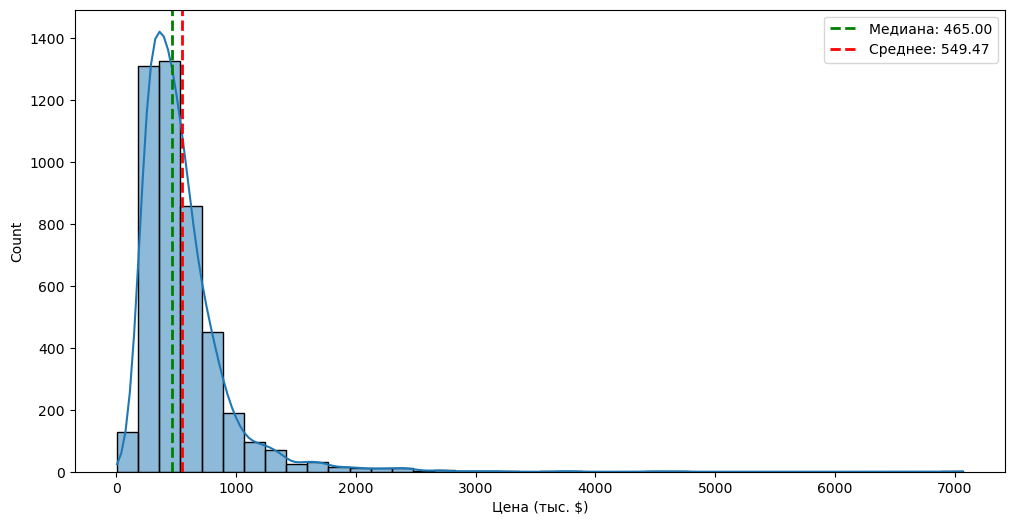

In [12]:
plt.figure(figsize=(12,6))

ax = sns.histplot(df['price'] / 1000, bins=40, kde=True)

median_val = (np.median(df['price'])) / 1000
mean_val = (np.mean(df['price'])) / 1000

plt.axvline(
    median_val,
    color='green',
    linestyle='--',
    linewidth=2,
    label = f'Медиана: {median_val:.2f}'
)
plt.axvline(
    mean_val, 
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Среднее: {mean_val:.2f}'
)

plt.xlabel('Цена (тыс. $)')
plt.legend()
plt.show()

Text(0.5, 0, 'Цена (тыс. $)')

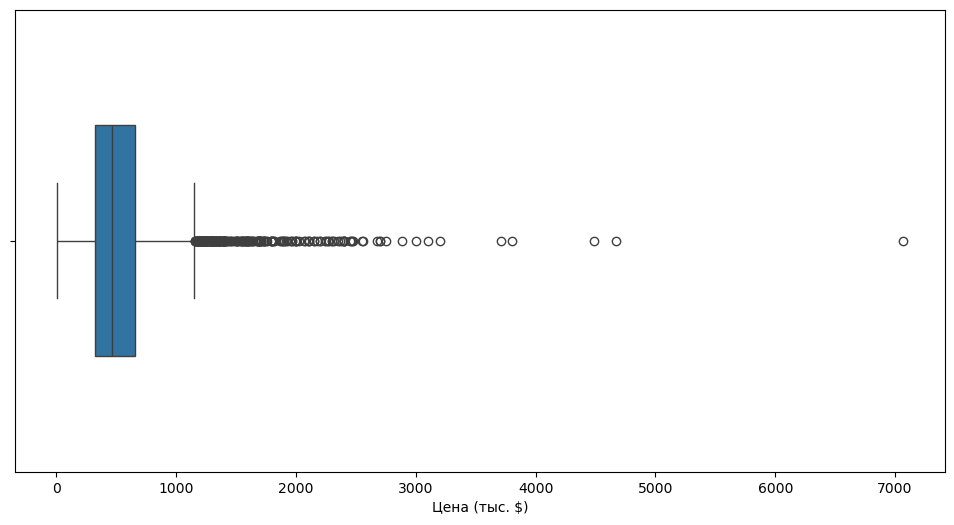

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x=(df['price']) / 1000, width=.5)
plt.xlabel('Цена (тыс. $)')

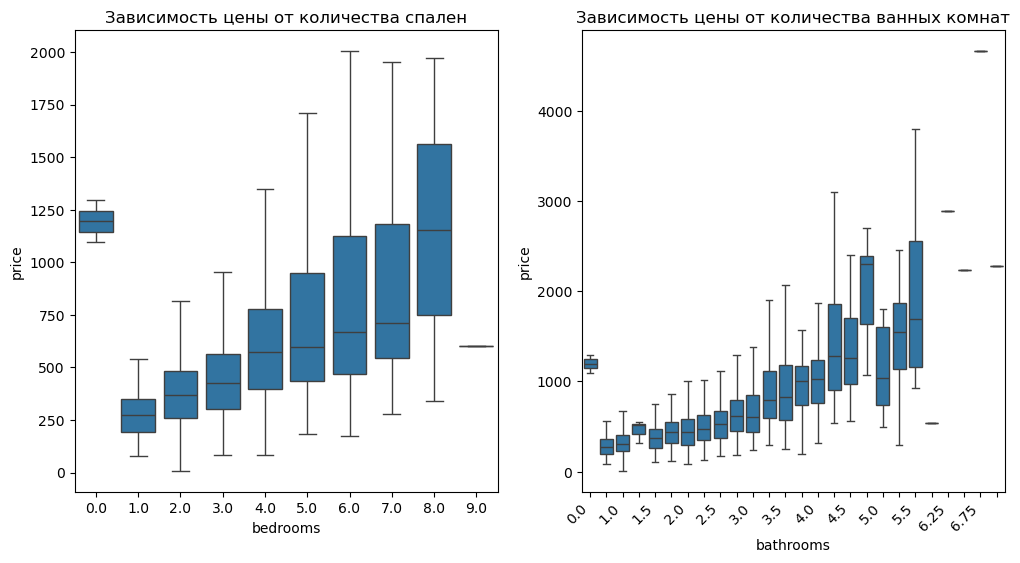

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.boxplot(x=df['bedrooms'], y=(df['price']) / 1000, ax=ax[0], showfliers=False)
sns.boxplot(x=df['bathrooms'], y=(df['price']) / 1000, ax=ax[1], showfliers=False)

ax[0].set_title('Зависимость цены от количества спален')
ax[1].set_title('Зависимость цены от количества ванных комнат')
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right")

for index, label in enumerate(ax[1].xaxis.get_ticklabels()):
    if index % 2 != 0:
        label.set_visible(False)

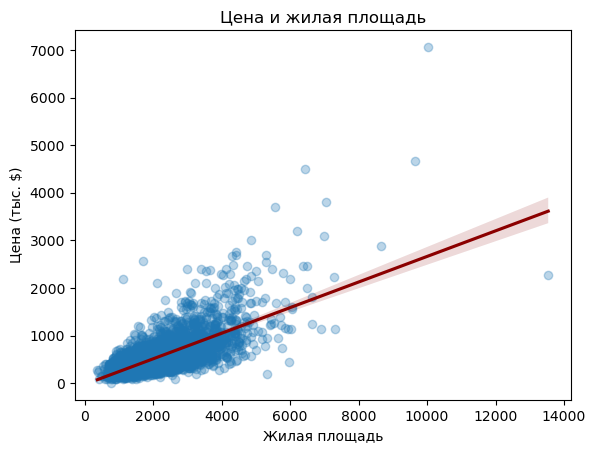

In [15]:
sns.regplot(x=df['sqft_living'], y=(df['price'] / 1000), scatter_kws={'alpha': .3}, line_kws={'color': 'darkred'} )
plt.title('Цена и жилая площадь')
plt.xlabel('Жилая площадь')
plt.ylabel('Цена (тыс. $)')
plt.show()

In [16]:
num_cols = ['price',
            'bedrooms',
            'bathrooms',
            'sqft_living',
            'sqft_lot',
            'floors',
            'waterfront',
            'view',
            'condition',
            'sqft_above',
            'sqft_basement',
            'yr_built',
            'yr_renovated',
            'price_per_sqft'
           ]

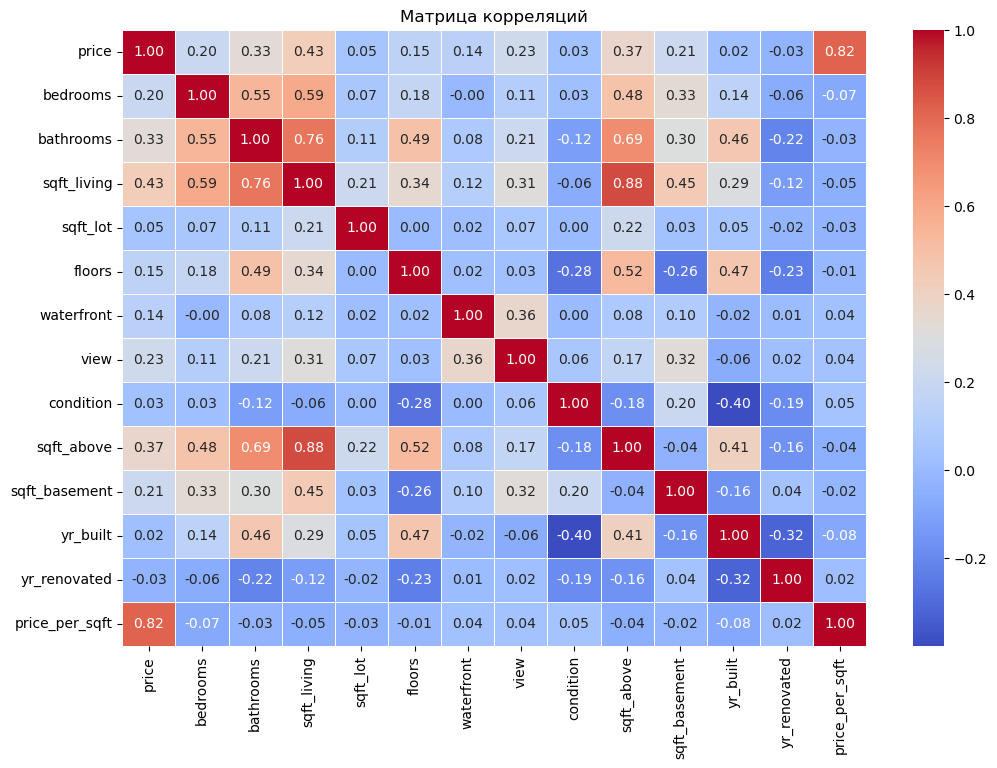

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(data[num_cols].corr(), annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

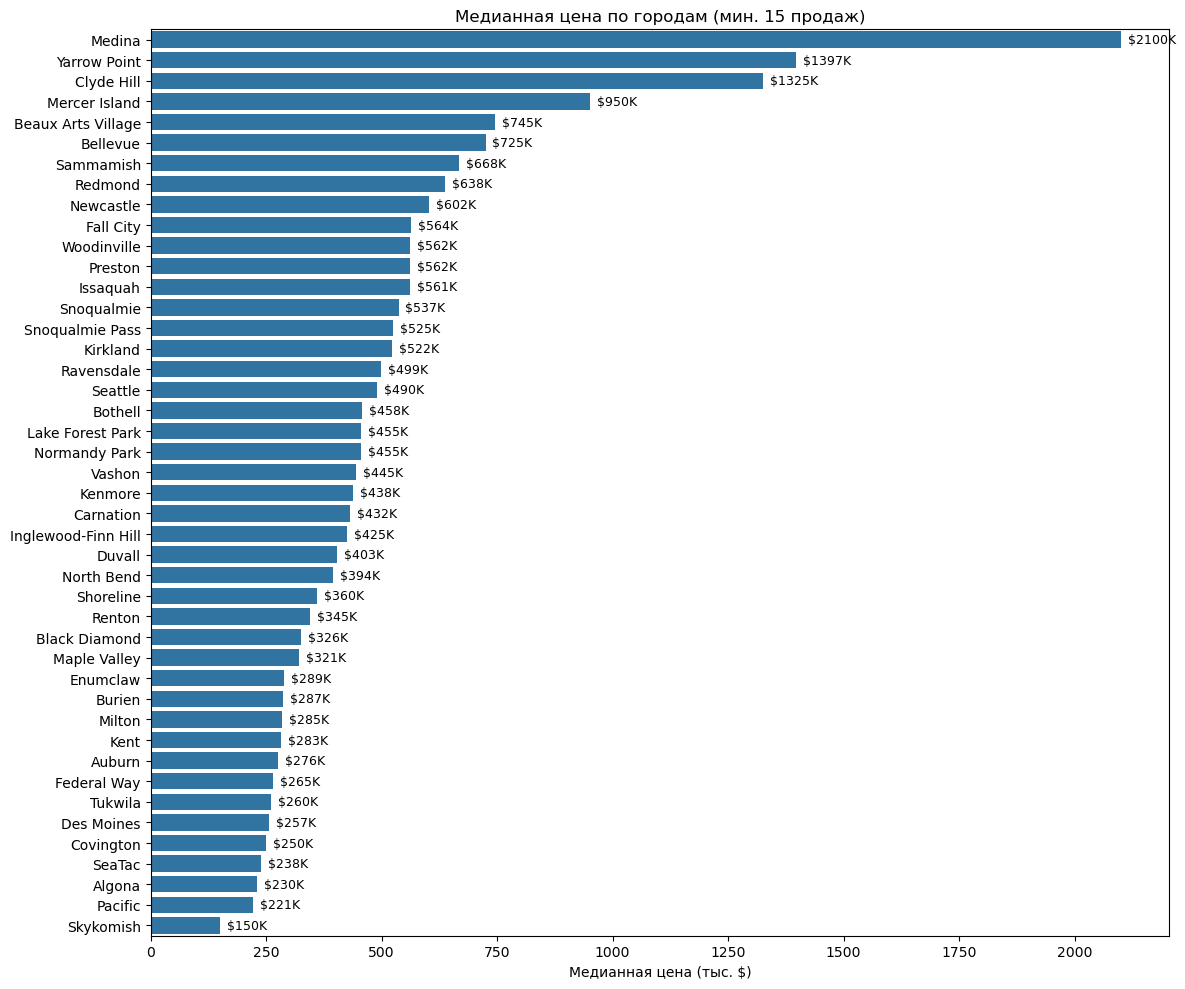

In [18]:
city_stats = df.groupby('city')['price'].agg(['median','count']).sort_values('median', ascending=False)
city_stats_scaled = city_stats['median'] / 1000

plt.figure(figsize=(12, 10))

sns.barplot(x=city_stats_scaled, y=city_stats.index)

plt.title('Медианная цена по городам (мин. 15 продаж)')
plt.xlabel('Медианная цена (тыс. $)')
plt.ylabel('')

for container in plt.gca().containers:
    labels = [f"${v.get_width():.0f}K" for v in container]
    plt.gca().bar_label(container, labels=labels, padding=5, fontsize=9)

plt.tight_layout()
plt.show()

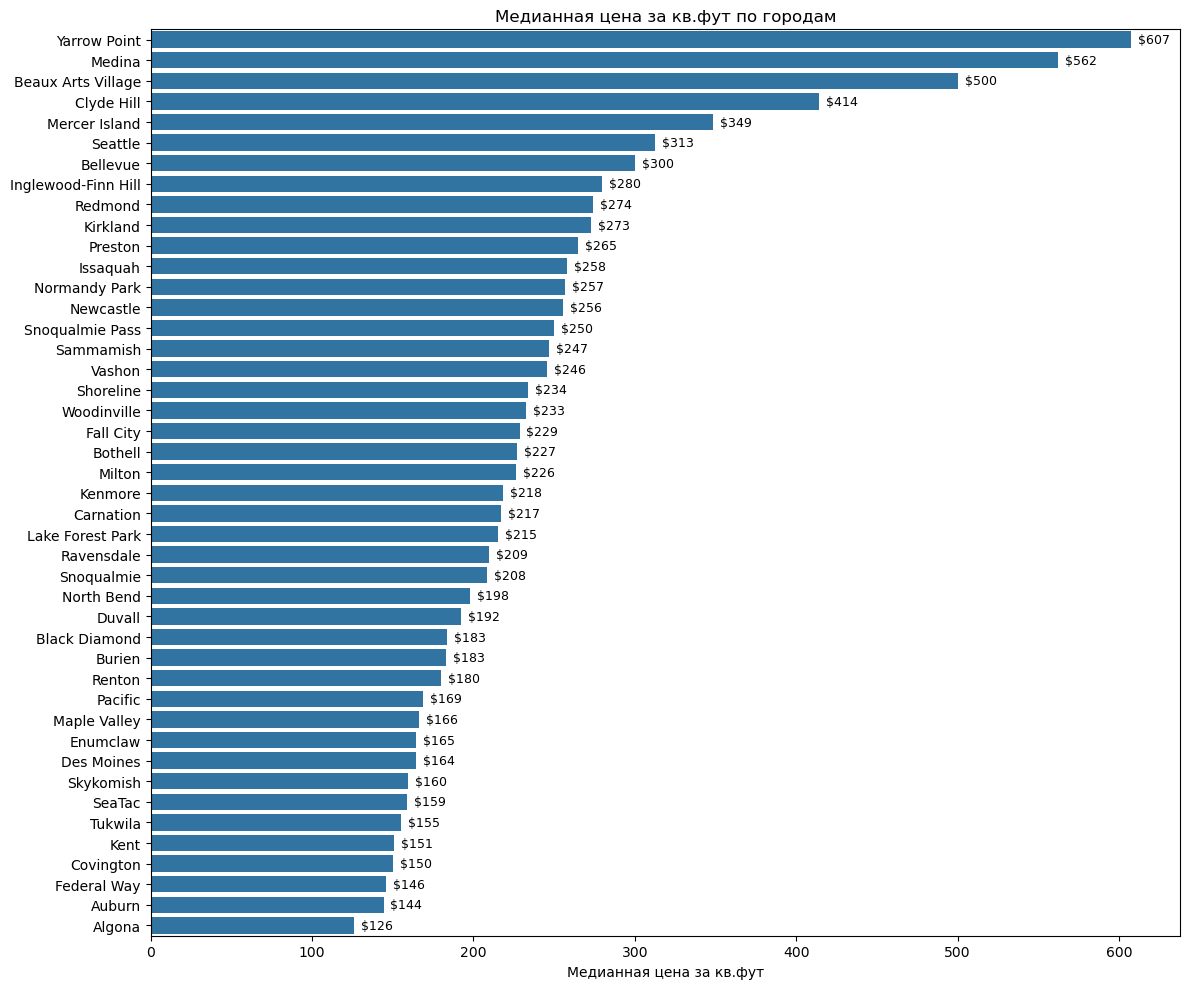

In [19]:
plt.figure(figsize=(12, 10))

city_order = df.groupby('city')['price_per_sqft'].median().sort_values(ascending=False).index

sns.barplot(x=df['price_per_sqft'], y=df['city'], order=city_order, errorbar=None, estimator='median')

plt.title('Медианная цена за кв.фут по городам')
plt.xlabel('Медианная цена за кв.фут')
plt.ylabel('')

for container in plt.gca().containers:
    labels = [f"${v.get_width():.0f}" for v in container]
    plt.gca().bar_label(container, labels=labels, padding=5, fontsize=9)

plt.tight_layout()
plt.show()

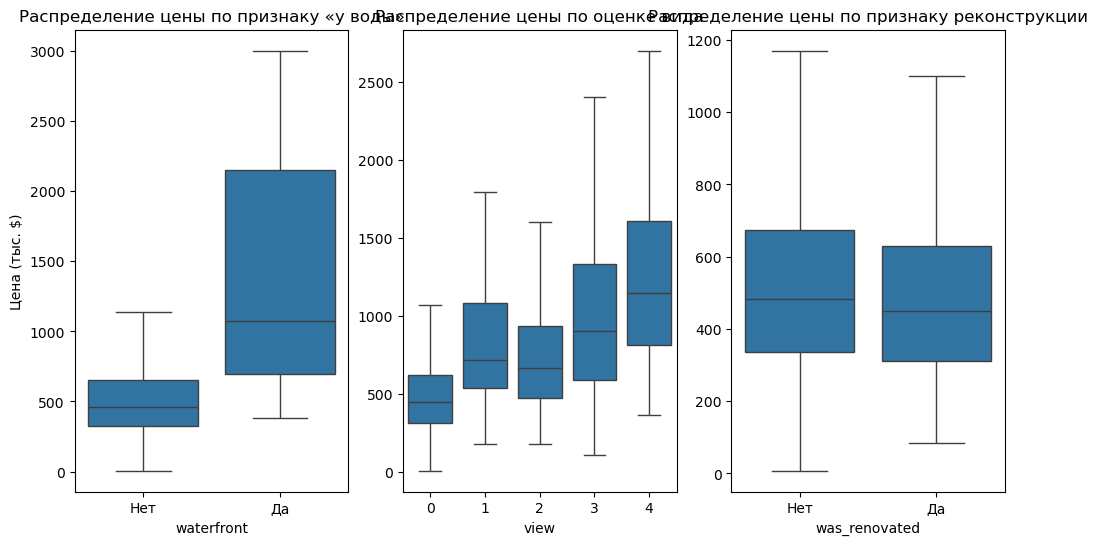

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

sns.boxplot(x=df['waterfront'], y=(df['price']) / 1000, ax=ax[0], showfliers=False)
sns.boxplot(x=df['view'], y=(df['price'] / 1000), ax=ax[1], showfliers=False)
sns.boxplot(x=df['was_renovated'], y=(df['price']) / 1000, ax=ax[2], showfliers=False)

ax[0].set_title('Распределение цены по признаку «у воды»')
ax[0].set_ylabel('Цена (тыс. $)')
ax[0].set_xticks(ax[0].get_xticks())
ax[0].set_xticklabels(['Нет', 'Да'])

ax[1].set_title('Распределение цены по оценке вида')
ax[1].set_ylabel('')

ax[2].set_title('Распределение цены по признаку реконструкции')
ax[2].set_ylabel('')
ax[2].set_xticks(ax[2].get_xticks())
ax[2].set_xticklabels(['Нет', 'Да'])

plt.show()

# Итоговый отчёт

## 1. Качество данных
С технической точки зрения датасет оказался чистым: пропущенных значений и дублирующихся строк среди всех 4 600 записей не обнаружено. Тем не менее, перед анализом потребовалось устранить три проблемы:
- **49 объявлений (1,1%) с ценой \\$0** — это не реальные рыночные сделки (вероятно, дарение, отчуждение за долги или технические заглушки), они были удалены.
- **1 экстремальный выброс** — продажа в Кенте за \\$26,59 млн при цене \\$22 534 за кв. фут, что примерно в 70 раз превышает медиану по датасету (\\$266 за кв. фут). Вместе со вторым пограничным значением были удалены 2 строки (0,04%) с ценой выше \\$2000 за кв. фут — как ошибки ввода данных.
- **2 объявления (0,04%) с 0 спален** были оставлены в датасете — правдоподобно как сделки, где ценность представляет только земля, а не постройка.
- Столбец `date` хранился как текст и был приведён к формату datetime.

После очистки для анализа осталось 4 549 строк (98,9% от исходного объёма данных).

## 2. Распределение цены
Распределение цены имеет правостороннюю асимметрию: медиана составляет **\\$465 тыс.**, тогда как среднее значение смещено вверх до **\\$549 тыс.** из-за длинного «хвоста» дорогих продаж, доходящих до \\$7,06 млн. Диаграмма размаха показывает, что «нормальный» рынок находится примерно ниже \\$1,15 млн, а выше этой границы — заметный кластер элитных выбросов. **Медиана, а не среднее, является более репрезентативной статистикой для этого рынка.**

## 3. Корреляции с ценой
Главный реальный драйвер цены — жилая площадь: `sqft_living` (r = 0,70), `sqft_above` (r = 0,60) и `bathrooms` (r = 0,52) показывают умеренную положительную связь. `view` (0,38) и `bedrooms` (0,33) влияют слабее. Площадь участка, состояние, год постройки и год реконструкции показывают **корреляцию, близкую к нулю** (все |r| ≤ 0,08) — на этом рынке ценность формируют размер и качество объекта, а не возраст или площадь участка.

## 4. Цена по городам
Город — главный фактор, определяющий цену. Медианные цены варьируются **от \\$2,10 млн в Медине до \\$150 тыс. в Скайкомише** — разница в 14 раз.
- **Лидеры:** Медина, Йерроу-Пойнт, Клайд-Хилл, Мёрсер-Айленд, Бо-Артс-Виллидж, Беллевью — престижные прибрежные районы на восточном берегу озера.
- **Аутсайдеры:** Скайкомиш, Пасифик, Алгона, Си-Так, Ковингтон, Де-Мойн.
- По **цене за квадратный фут** Йерроу-Пойнт (\\$607) фактически обгоняет Медину (\\$562) — это говорит о том, что дома там меньше по площади, но премия за землю ещё выше. Сиэтл не входит в топ по абсолютной цене (17-е место, \\$490 тыс.), но занимает 6-е место по цене за кв.фут (\\$313), что отражает высокий спрос на плотную городскую застройку.

## 5. Вода, оценка вида и реконструкция
- **Наличие водоёма (`waterfront`)** — самый сильный категориальный ценовой сигнал после города: медианная цена **примерно удваивается** (\~\\$450 тыс. → \~\\$1,05 млн+) для объектов у воды, с гораздо более широким разбросом.
- **Оценка вида (`view`)** показывает чёткую монотонную зависимость: медианная цена стабильно растёт от view=0 (\~\\$450 тыс.) до view=4 (\~\\$1,2 млн).
- **Статус реконструкции**, вопреки ожиданиям, почти не даёт ценовой премии — у реконструированных домов медианная цена сопоставима или даже немного ниже, чем у нереконструированных, что согласуется с близкой к нулю корреляцией. Вероятное объяснение: реконструкцию чаще делают в более старых домах, чтобы просто «подтянуть» их до рыночного стандарта, а не добавить ценность сверх уже актуального состояния — сам по себе этот флаг ненадёжен как самостоятельный ценовой сигнал.
